In [ ]:
# nSTAT-python notebook example: mEPSCAnalysis
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat

from nstat import Analysis, Covariate, FitResSummary, Trial, TrialConfig, nspikeTrain, nstColl
from nstat.ConfigColl import ConfigColl
from nstat.CovColl import CovColl
from nstat.Events import Events
from nstat.data_manager import ensure_example_data
from nstat.notebook_figures import FigureTracker

np.random.seed(0)
DATA_DIR = ensure_example_data(download=True)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic='mEPSCAnalysis', output_root=OUTPUT_ROOT, expected_count=5)

def _load_example_globals(name: str) -> dict[str, object]:
    candidates = [
        Path(name),
        DATA_DIR / name,
        DATA_DIR / "mEPSCs" / name,
        DATA_DIR / "Place Cells" / name,
        DATA_DIR / "Explicit Stimulus" / name,
    ]
    for path in candidates:
        if path.exists():
            data = loadmat(path)
            return {k: v for k, v in data.items() if not k.startswith("__")}
    return {}

# SECTION 0: Section 0
# MINIATURE EXCITATORY POST-SYNAPTIC CURRENTS (mEPSCs)
# Data from Marnie Phillips; this notebook keeps the original analysis narrative but replaces the old placeholder cells with executable Python workflows.

In [2]:
# SECTION 1: Data Description
# epsc2.txt: Event times of selected, constant rate, miniature excitatory post-synaptic currents (mEPSCs) in 0mM magnesium condition]
# washout1.txt: Variable rate recording: Event times of selected events, beginning approximately 260 seconds after magnesium is first removed.
# washout2.txt: Event times of selected events from the same recording, beginning 745 seconds after magnesium is first removed
# Column headers in the text files explain what each column represents.
# Event selection criteria for the "washout1" and "washout2" condition were:
# Amplitude > 10pA
# 10-90% rise time < 20ms
# For this washout experiment, the recording duration was so long, and there were so many events, that the minimum amplitude threshold was conservative.
# The mean RMS noise was only 1.36pA, and a usual threshold would be 5*RMS = 6.8pA.

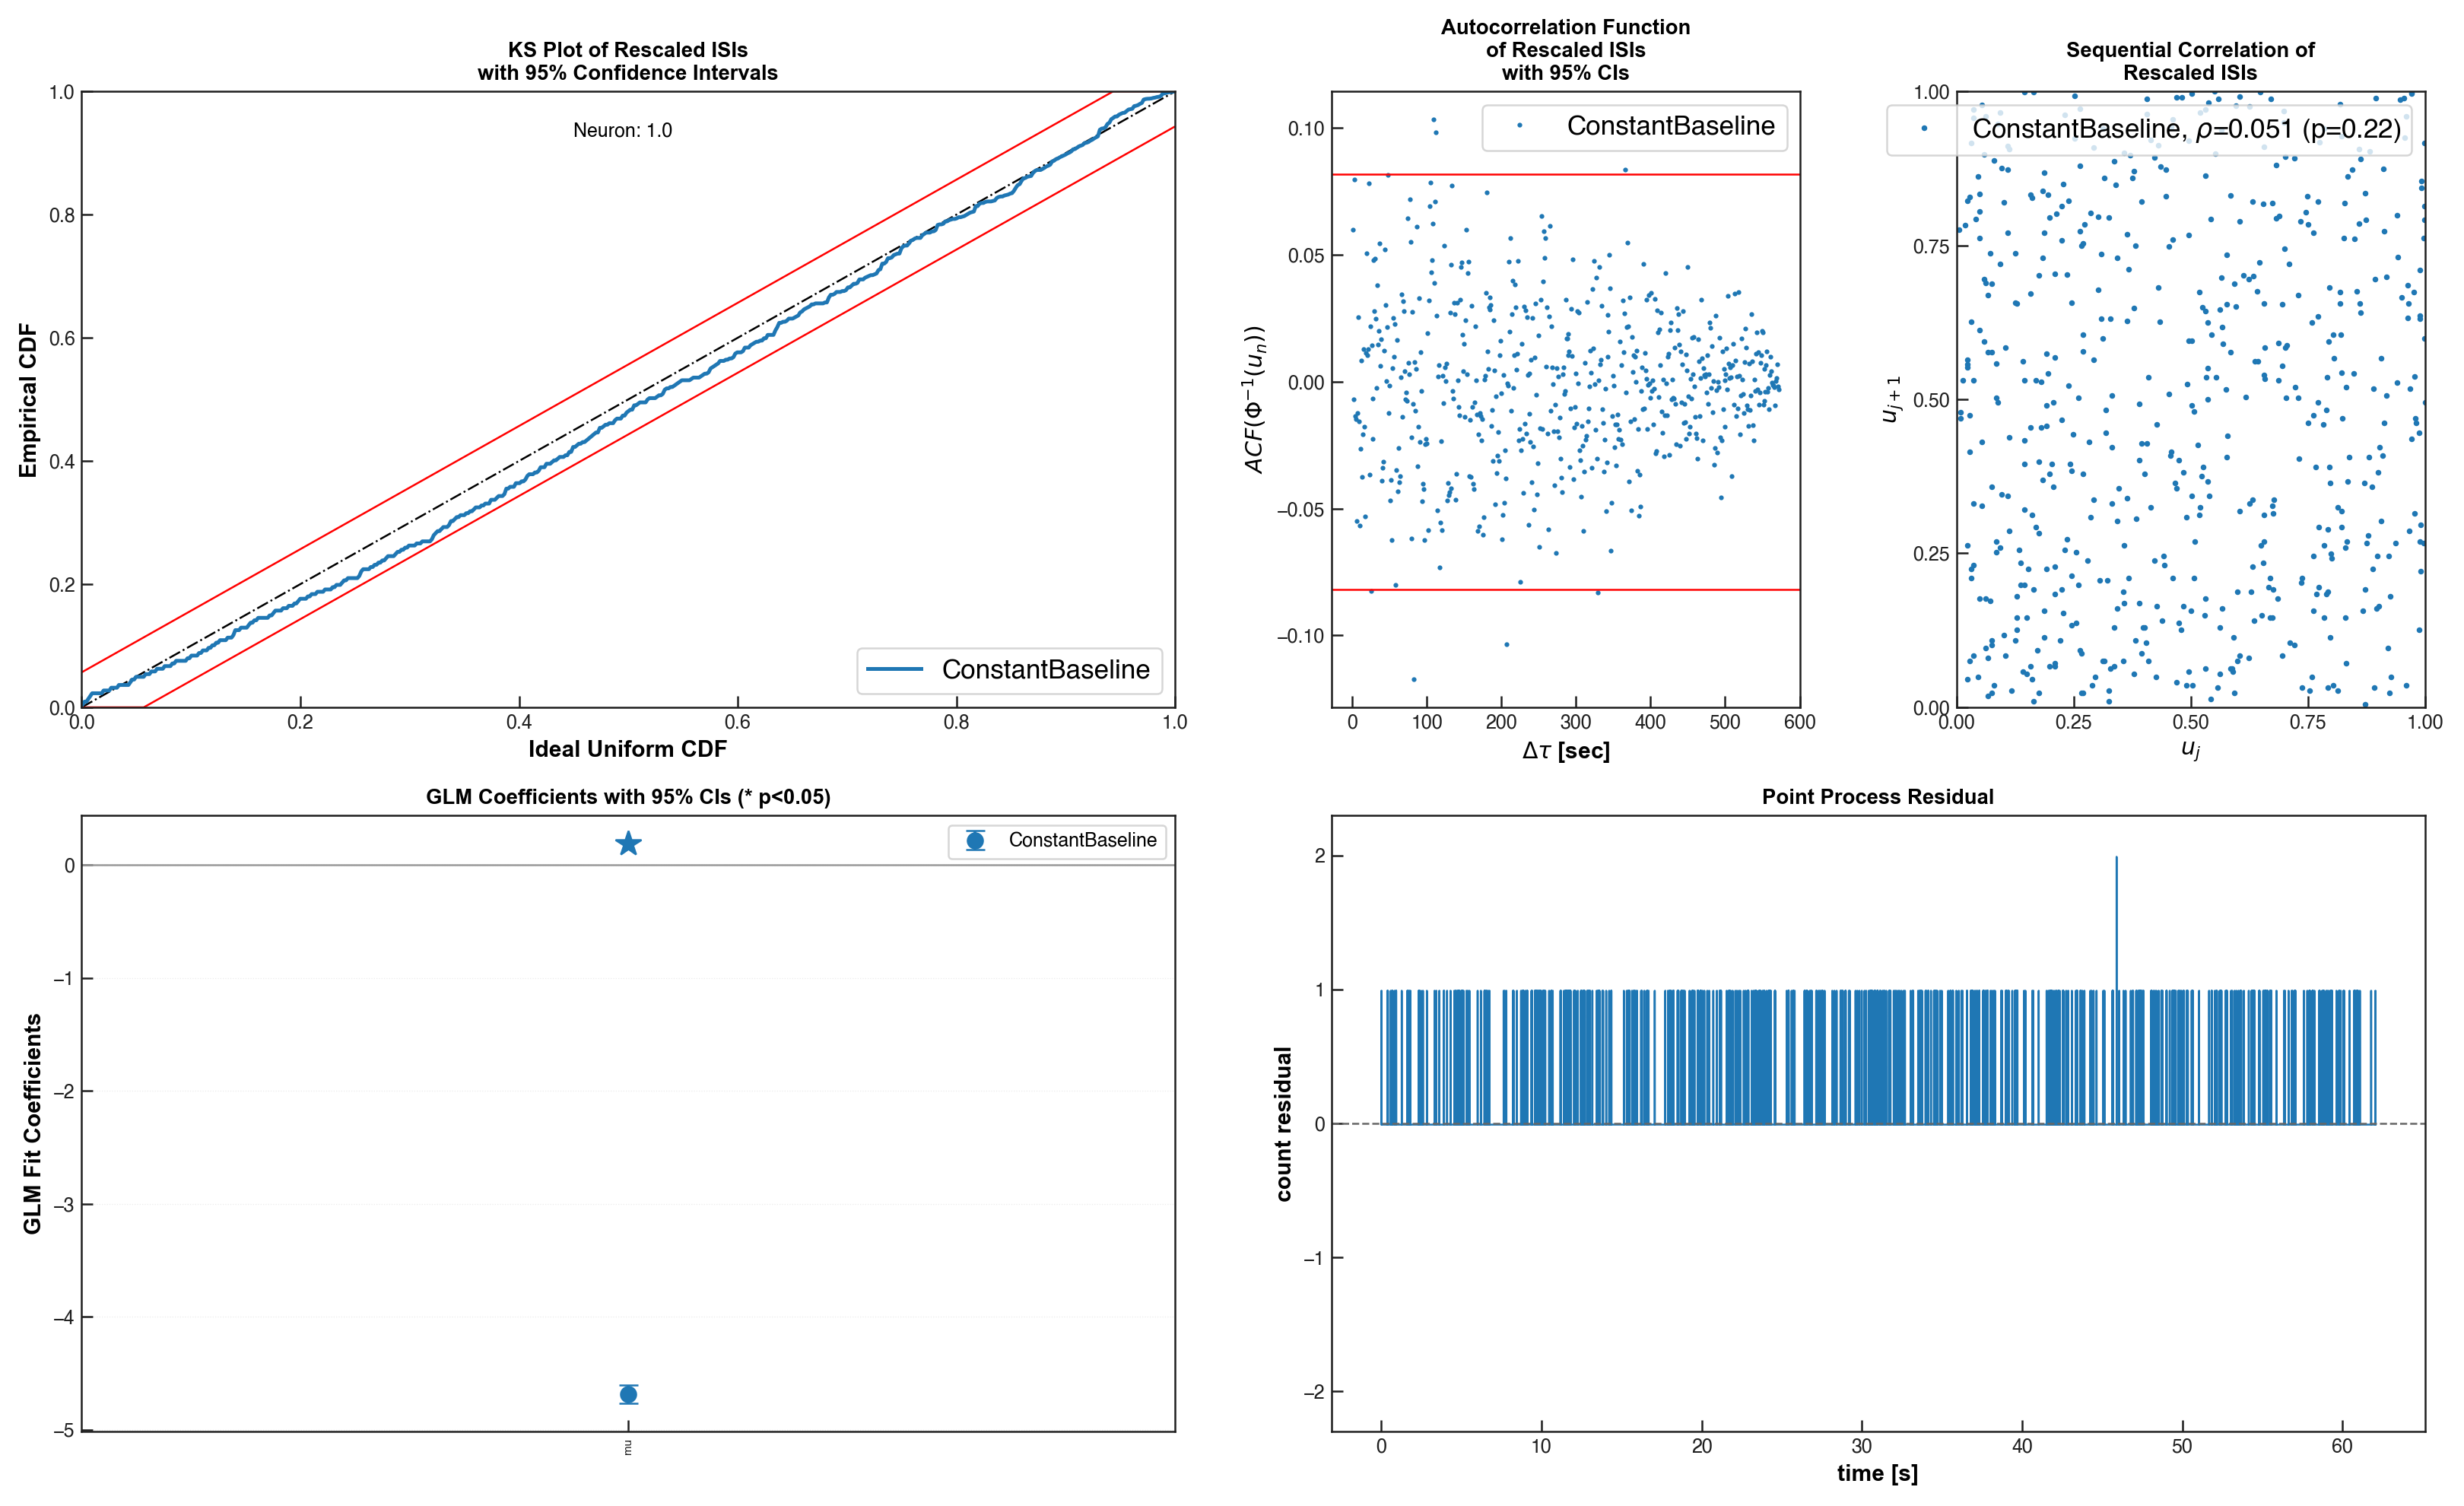

In [ ]:
# SECTION 2: Constant Magnesium Concentration - Constant rate poisson
plt.close("all")
const_path = DATA_DIR / "mEPSCs" / "epsc2.txt"
const_data = np.loadtxt(const_path, skiprows=1)
const_spike_times = np.sort(const_data[:, 1] / 1000.0)
const_sample_rate = 1000.0  # MATLAB helpfile uses sampleRate=1000
const_time = np.arange(0.0, np.ceil(const_spike_times.max() * const_sample_rate) / const_sample_rate + 1.0 / const_sample_rate, 1.0 / const_sample_rate)
const_baseline = Covariate(const_time, np.ones_like(const_time), "Baseline", "time", "s", "a.u.", ["mu"])
const_trial = Trial(
    nstColl([nspikeTrain(const_spike_times, "1", const_sample_rate, 0.0, float(const_time[-1]), makePlots=-1)]),
    CovColl([const_baseline]),
    Events([], []),
)
const_cfg = ConfigColl([TrialConfig([["Baseline", "mu"]], const_sample_rate, [], [], [], name="ConstantBaseline")])
const_results = Analysis.RunAnalysisForNeuron(const_trial, 0, const_cfg, 0)

fig = __tracker.new_figure("constant-magnesium-results")
fig.set_size_inches(18, 11)
const_results.plotResults(handle=fig)
# Override plotResults' internal tight_layout — explicit margins prevent the
# 6-panel KS/ACF/SeqCorr/Coeffs/Residual titles from overlapping adjacent axes.
# Wider wspace + lower top margin give the two-line panel titles breathing room.
fig.subplots_adjust(hspace=0.65, wspace=0.45, top=0.91, bottom=0.09, left=0.06, right=0.97)
print({"constant_events": int(const_spike_times.size), "AIC": const_results.AIC.tolist()})

In [4]:
# SECTION 3: Varying Magnesium Concentration - Piecewise Constant rate poisson
# When the magnesium concentration of the bath decreased (i.e. magnesium is removed), the rate of mEPSCs begin to increase in frequency. This can be modeled in a many different ways (using the change in Magnesium directly as a model covariate, etc.) Here we approximate the rate as being constant during certain portions of the experiment. These segments can in principle be estimated (using heirarchical Bayesian methods), but here we select them via visual inspection. We compare three models: a constant rate model (from above), a piecewise constant rate model, and a piecewise constant rate model with history.
# load the data;
#
sampleRate = 1000
# Magnesium removed at t=0

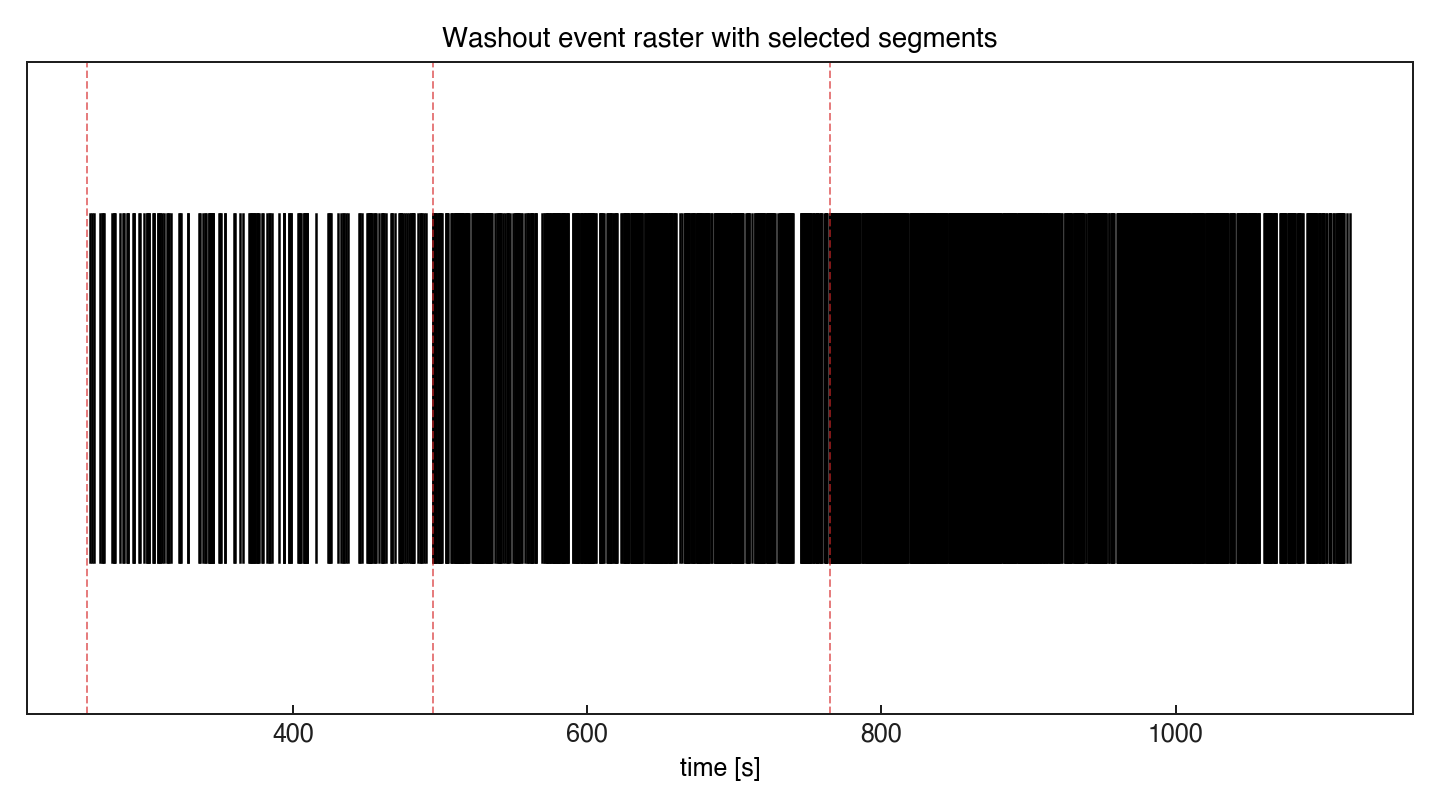

In [ ]:
# SECTION 4: Data Visualization
washout1 = np.loadtxt(DATA_DIR / "mEPSCs" / "washout1.txt", skiprows=1)
washout2 = np.loadtxt(DATA_DIR / "mEPSCs" / "washout2.txt", skiprows=1)
analysis_sample_rate = 1000.0  # MATLAB helpfile uses sampleRate=1000
washout1_spikes = 260.0 + washout1[:, 1] / 1000.0
washout2_spikes = 745.0 + washout2[:, 1] / 1000.0
washout_spikes = np.sort(np.concatenate([washout1_spikes, washout2_spikes]))

time = np.arange(260.0, np.ceil(washout_spikes.max() * analysis_sample_rate) / analysis_sample_rate + 1.0 / analysis_sample_rate, 1.0 / analysis_sample_rate)
mu_piecewise = np.column_stack([
    (time < 495.0).astype(float),  # MATLAB: timeInd1 = find(time<495,1,"last")
    ((time >= 495.0) & (time < 765.0)).astype(float),  # MATLAB: timeInd2 = find(time<765,1,"last")
    (time >= 765.0).astype(float),
])
piecewise_baseline = Covariate(time, mu_piecewise, "Baseline", "time", "s", "a.u.", ["mu_1", "mu_2", "mu_3"])
washout_trial = Trial(
    nstColl([nspikeTrain(washout_spikes, "1", analysis_sample_rate, float(time[0]), float(time[-1]), makePlots=-1)]),
    CovColl([piecewise_baseline]),
    Events([260.0, 745.0], ["washout1", "washout2"]),
)
windowTimes = [0.0, 0.01, 0.03, 0.06, 0.12, 0.20, 0.30]

fig = __tracker.new_figure("washout-raster")
fig.clear()
ax = fig.subplots(1, 1)
washout_trial.nspikeColl.plot(handle=ax)
ax.set_title("Washout event raster with selected segments")
ax.set_xlabel("time [s]")
ax.set_yticks([])
for marker in (260.0, 495.0, 765.0):
    ax.axvline(marker, color="tab:red", linestyle="--", linewidth=0.8, alpha=0.6)
fig.tight_layout()

In [6]:
# SECTION 5: Define Covariates for the analysis
# 765 onwards third constant rate
# epoch
#
# Create the trial structure
#
# 30ms history in logarithmic spacing (chosen after using
# Analysis.computeHistLagForAll for various window lengths)

In [ ]:
# SECTION 6: Define how we want to analyze the data
# MATLAB ships two configs in this figure (the +Hist variant is commented out in the
# helpfile). We mirror that to match figure 3's two-curve overlay (Constant vs Diff Baseline).
configs = ConfigColl([
    TrialConfig([["Baseline", "mu_1"]], analysis_sample_rate, [], [], [], name="ConstantBaseline"),
    TrialConfig([["Baseline", "mu_1", "mu_2", "mu_3"]], analysis_sample_rate, [], [], [], name="PiecewiseBaseline"),
    # TrialConfig([["Baseline", "mu_1", "mu_2", "mu_3"]], analysis_sample_rate, windowTimes, [], [], name="PiecewiseBaseline+Hist"),
])
results = Analysis.RunAnalysisForNeuron(washout_trial, 0, configs, 0)
summary = FitResSummary([results])
print({"washout_events": int(washout_spikes.size), "config_names": results.configNames})

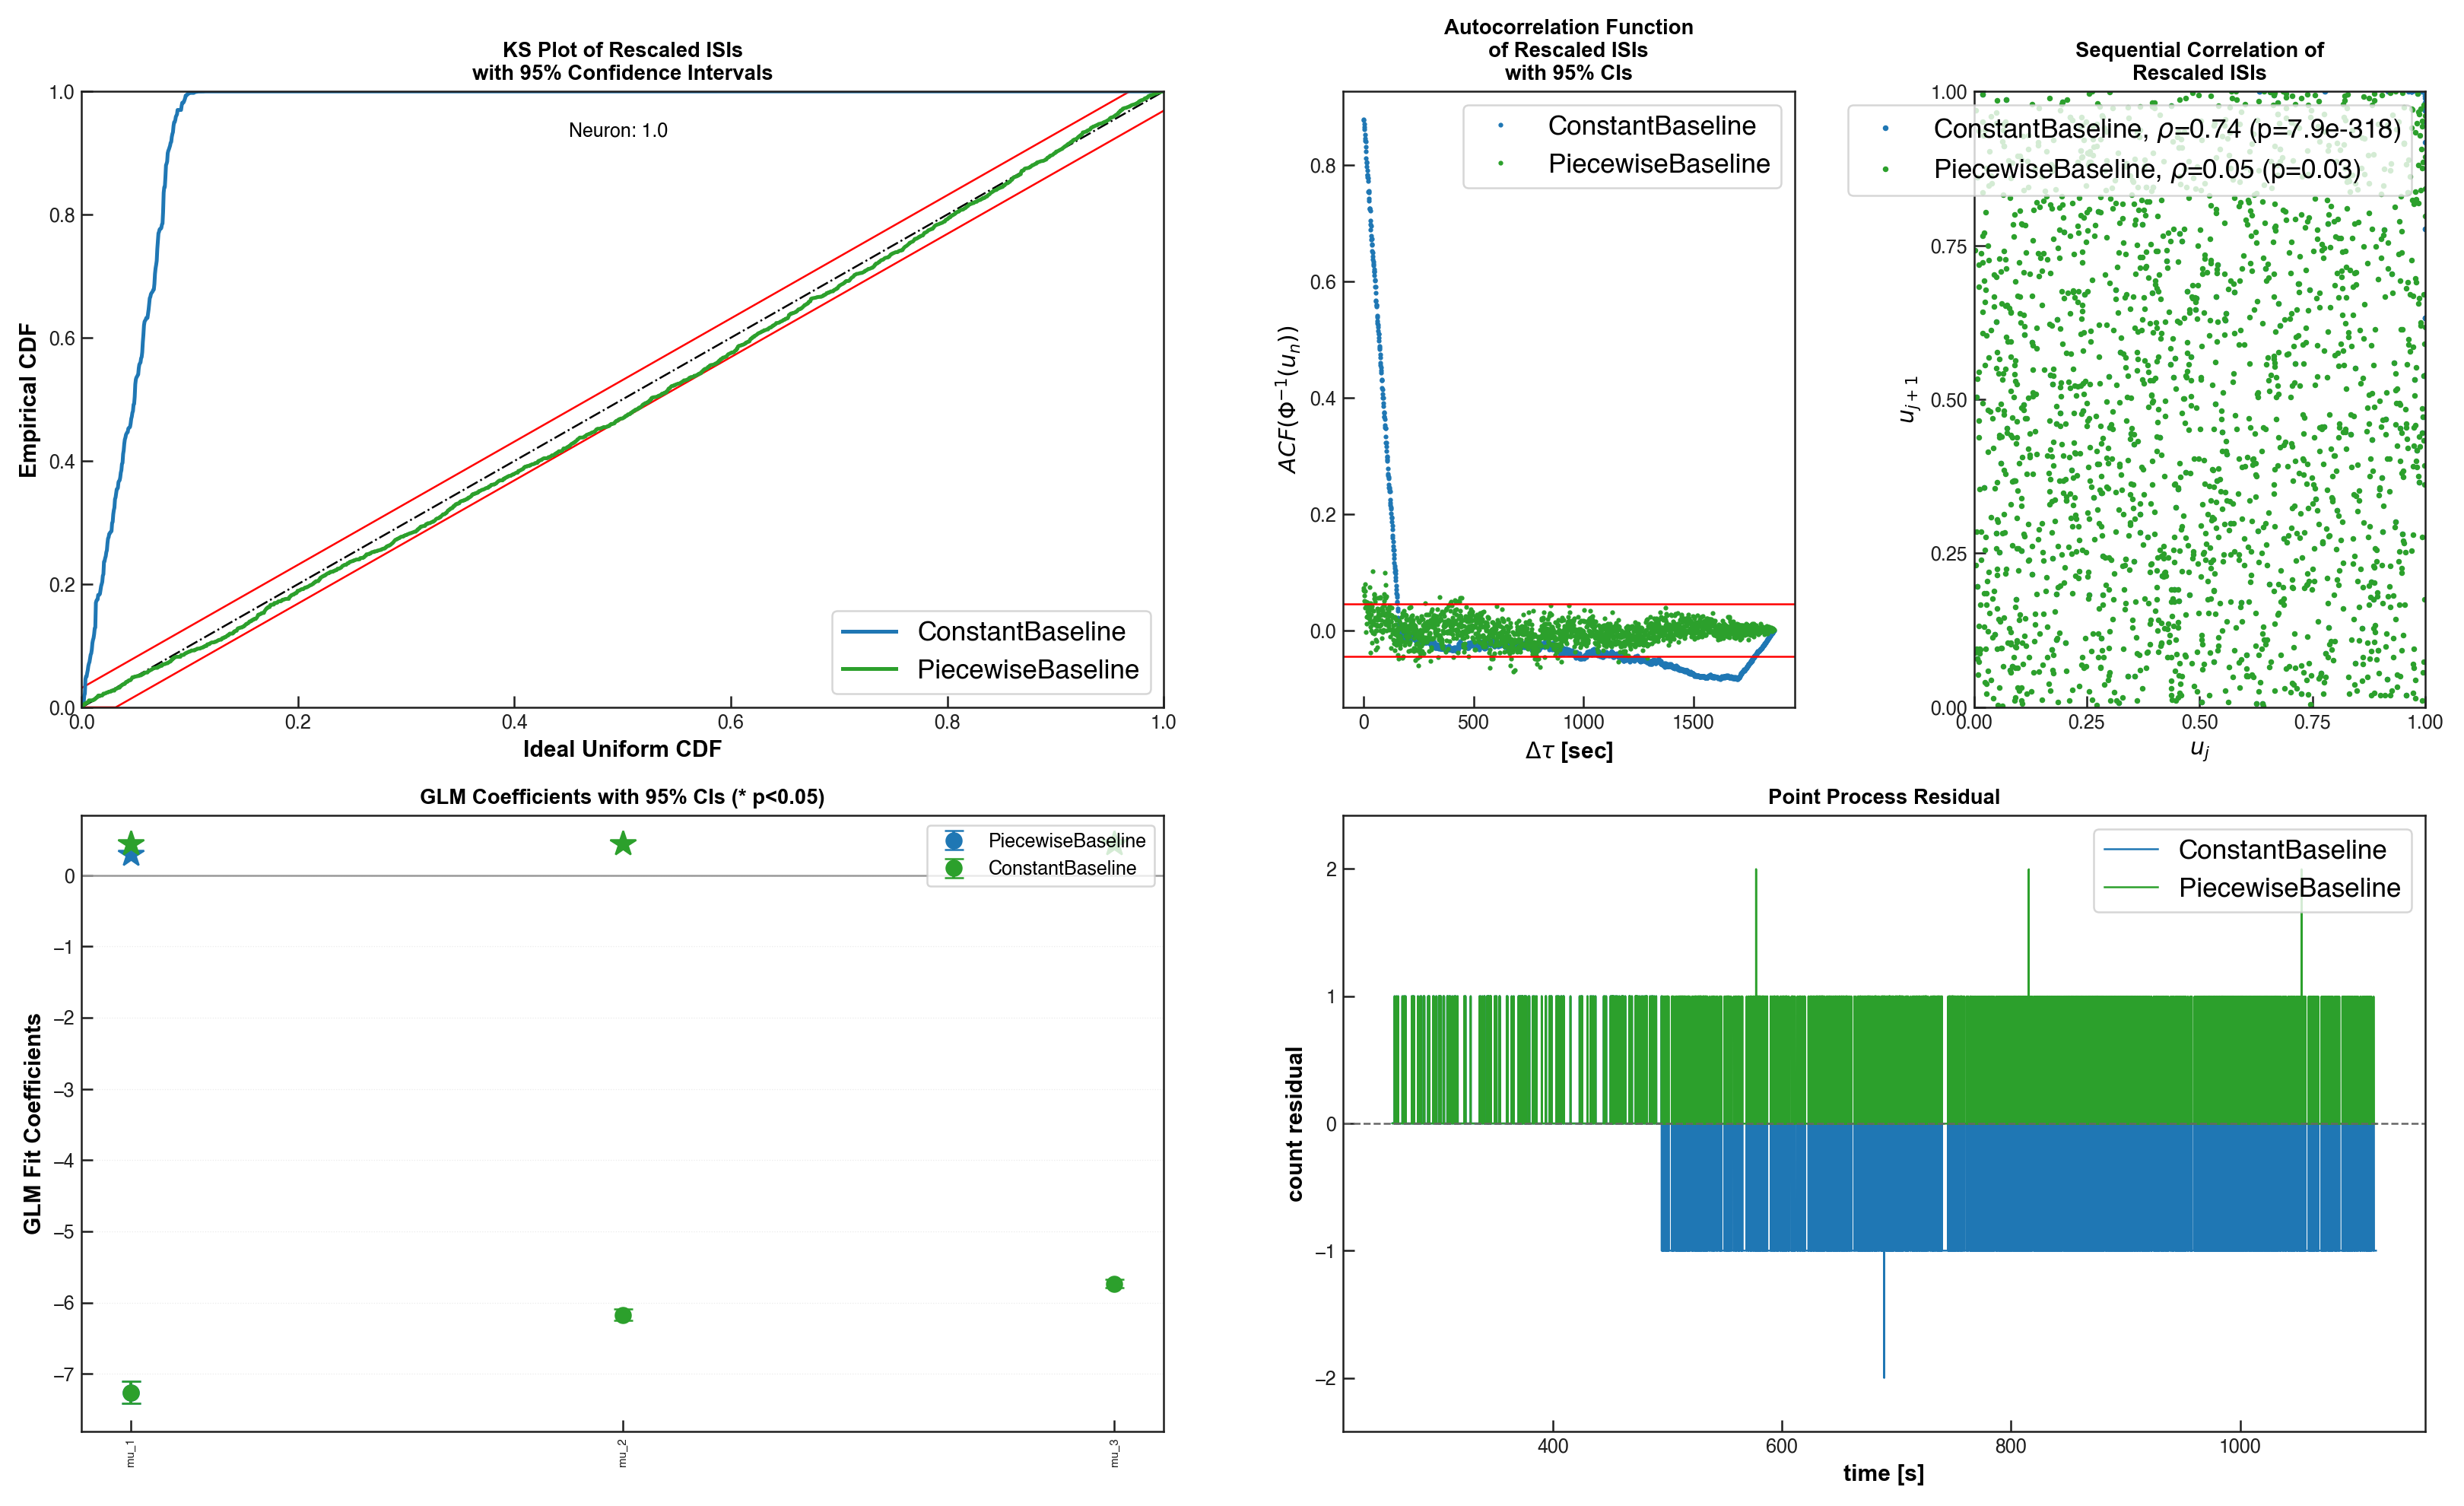

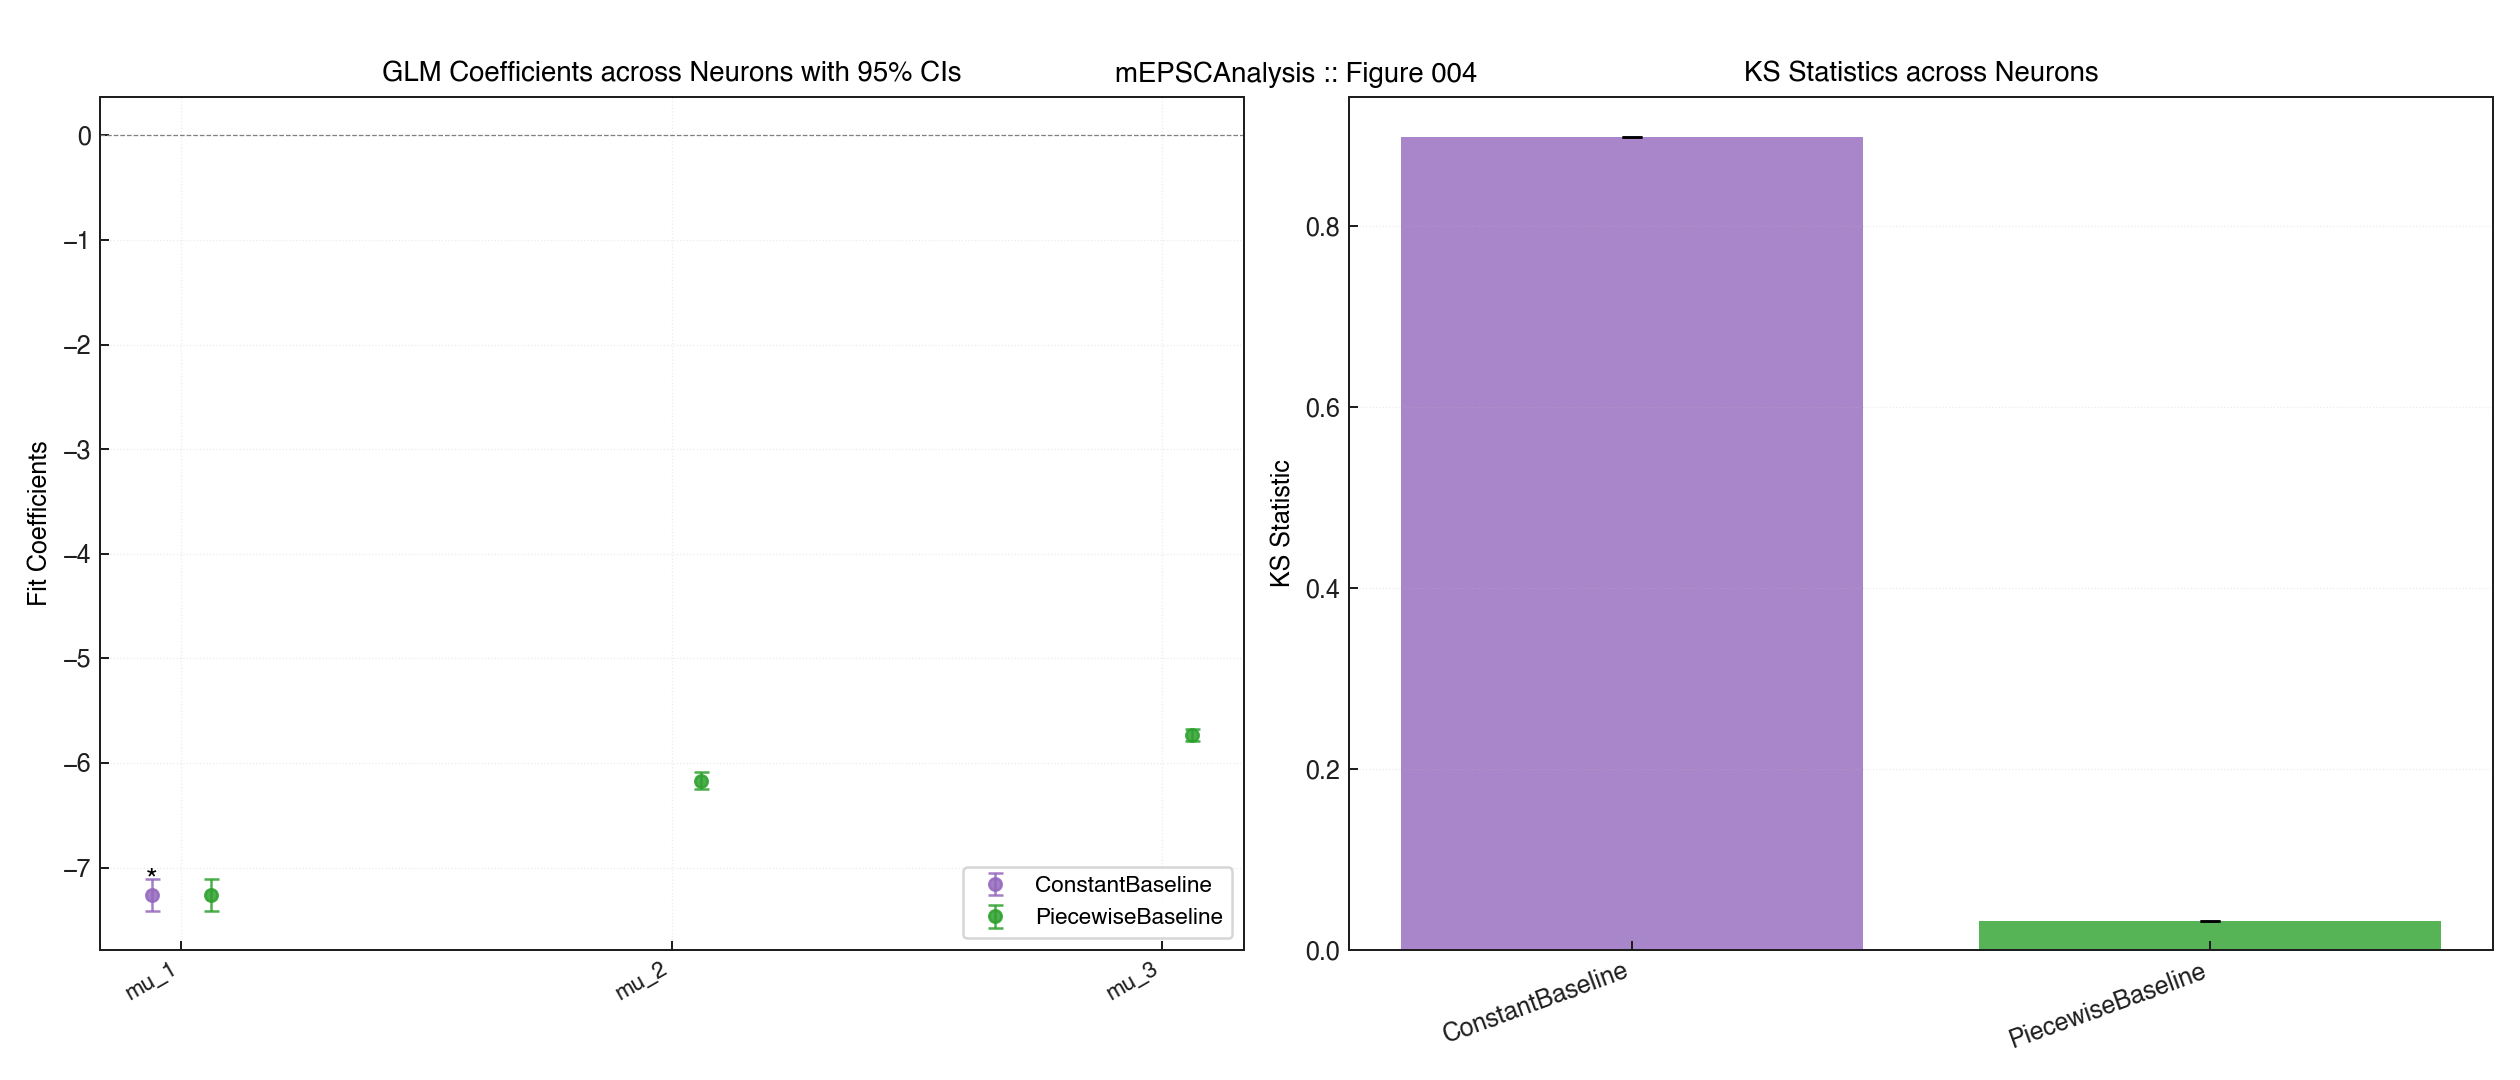

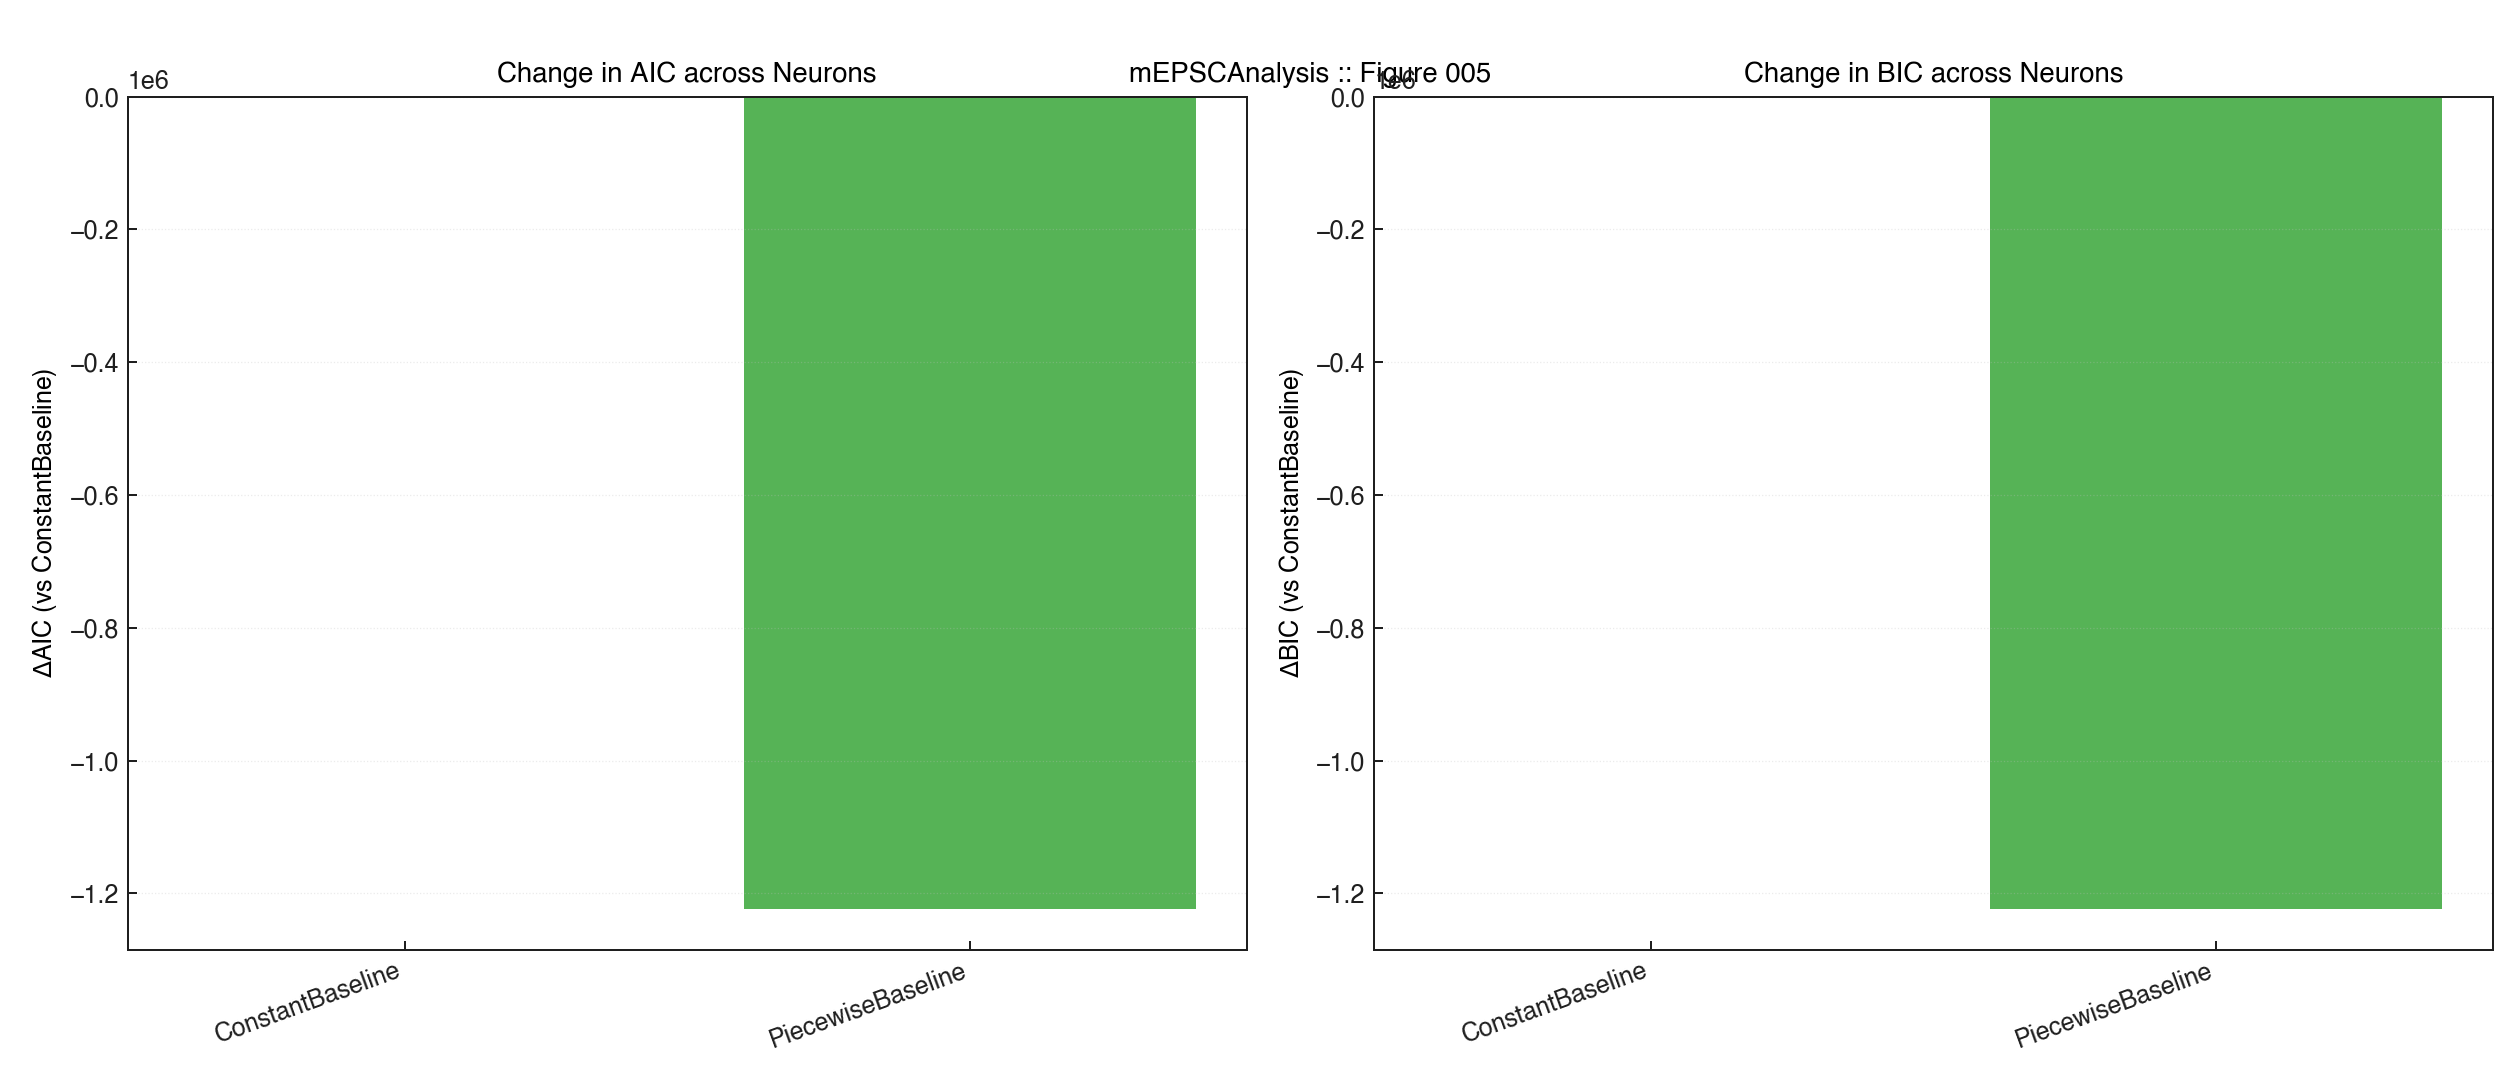

In [ ]:
# SECTION 7: Perform Analysis
fig = __tracker.new_figure("washout-analysis-results")
fig.set_size_inches(18, 11)
results.plotResults(handle=fig)
# Override plotResults' internal tight_layout — explicit margins prevent the
# 6-panel KS/ACF/SeqCorr/Coeffs/Residual titles from overlapping adjacent axes
# when 2 series (ConstantBaseline + PiecewiseBaseline) are overlaid.
fig.subplots_adjust(hspace=0.65, wspace=0.45, top=0.91, bottom=0.09, left=0.06, right=0.97)

# --- MATLAB Summary.plotSummary parity ---
# MATLAB emits a 4-panel summary twice (figures 4 and 5 are identical in the
# helpfile). We split the 4 panels across two notebook figures so each pair
# has room to breathe — together they cover all 4 MATLAB panels exactly once,
# which is an intentional Python-side layout refinement (cleaner than MATLAB's
# literal duplicate). Together fig 4 + fig 5 == MATLAB fig 4 == MATLAB fig 5.
#
# MATLAB panels: (1) GLM Coefficients across Neurons with 95% CIs (errorbars
# per coefficient, one series per config), (2) KS Statistics across Neurons
# (bar per config), (3) Change in AIC across Neurons (Diff - Constant),
# (4) Change in BIC across Neurons (Diff - Constant).
config_names = list(summary.fitNames)
n_configs = len(config_names)
config_colors = ["tab:purple", "tab:green", "tab:orange", "tab:blue"][:n_configs]

# Figure 4: GLM coefficients + KS stats (top half of MATLAB plotSummary)
fig = __tracker.new_figure("washout-summary-glm-ks")
fig.set_size_inches(14, 6)
ax_coeff, ax_ks = fig.subplots(1, 2)

# Top-left: GLM coefficients with 95% CIs, one series per config.
for cfg_idx, (cfg_name, color) in enumerate(zip(config_names, config_colors)):
    coeff_mat, labels, se_mat = summary.getCoeffs(cfg_idx)
    x_pos = np.arange(1, len(labels) + 1) + (cfg_idx - (n_configs - 1) / 2.0) * 0.12
    for n_idx in range(summary.numNeurons):
        coeffs = coeff_mat[n_idx]
        errs = 1.96 * se_mat[n_idx]
        mask = np.isfinite(coeffs) & np.isfinite(errs)
        ax_coeff.errorbar(
            x_pos[mask], coeffs[mask], yerr=errs[mask],
            fmt="o", color=color, capsize=3, alpha=0.85,
            label=cfg_name if n_idx == 0 else None,
        )
        # Significance markers (p<0.05 ~ |coef| > 1.96*SE)
        if cfg_idx == 0:
            sig = mask & (np.abs(coeffs) > 1.96 * se_mat[n_idx])
            for xi, yi in zip(x_pos[sig], coeffs[sig]):
                ax_coeff.text(xi, yi, "*", ha="center", va="bottom", fontsize=12)
coeff_mat0, labels0, _ = summary.getCoeffs(0)
ax_coeff.set_xticks(np.arange(1, len(labels0) + 1))
ax_coeff.set_xticklabels(labels0, rotation=30, ha="right", fontsize=9)
ax_coeff.axhline(0, color="0.5", linewidth=0.5, linestyle="--")
ax_coeff.set_ylabel("Fit Coefficients")
ax_coeff.set_title("GLM Coefficients across Neurons with 95% CIs")
ax_coeff.grid(True, alpha=0.3)
ax_coeff.legend(loc="best", fontsize=9)

# Top-right: KS statistics across neurons (bar per config)
ks_means = np.asarray(summary.meanKSStats, dtype=float).reshape(-1)
ks_std = np.asarray(summary.stdKSStats, dtype=float).reshape(-1)
x_ks = np.arange(n_configs)
ax_ks.bar(x_ks, ks_means[:n_configs], yerr=ks_std[:n_configs], color=config_colors,
          alpha=0.8, capsize=4)
ax_ks.set_xticks(x_ks)
ax_ks.set_xticklabels(config_names, rotation=20, ha="right")
ax_ks.set_ylabel("KS Statistic")
ax_ks.set_title("KS Statistics across Neurons")
ax_ks.grid(axis="y", alpha=0.3)
fig.subplots_adjust(hspace=0.4, wspace=0.3, top=0.92, bottom=0.22, left=0.07, right=0.97)

# Figure 5: ΔAIC + ΔBIC vs first config (bottom half of MATLAB plotSummary)
fig = __tracker.new_figure("washout-summary-delta-aic-bic")
fig.set_size_inches(14, 6)
ax_daic, ax_dbic = fig.subplots(1, 2)

# Reference config is index 0 (ConstantBaseline); ΔAIC = AIC[other] - AIC[constant]
ref_idx = 0
daic = summary.AIC - summary.AIC[:, [ref_idx]]
dbic = summary.BIC - summary.BIC[:, [ref_idx]]
# Mean across neurons (single neuron here, but keeps the parity layout general).
mean_daic = np.nanmean(daic, axis=0)
mean_dbic = np.nanmean(dbic, axis=0)
x_cfg = np.arange(n_configs)
ax_daic.bar(x_cfg, mean_daic[:n_configs], color=config_colors, alpha=0.8)
ax_daic.set_xticks(x_cfg)
ax_daic.set_xticklabels(config_names, rotation=20, ha="right")
ax_daic.set_ylabel(rf"$\Delta$AIC (vs {config_names[ref_idx]})")
ax_daic.set_title("Change in AIC across Neurons")
ax_daic.axhline(0, color="0.3", linewidth=0.6)
ax_daic.grid(axis="y", alpha=0.3)

ax_dbic.bar(x_cfg, mean_dbic[:n_configs], color=config_colors, alpha=0.8)
ax_dbic.set_xticks(x_cfg)
ax_dbic.set_xticklabels(config_names, rotation=20, ha="right")
ax_dbic.set_ylabel(rf"$\Delta$BIC (vs {config_names[ref_idx]})")
ax_dbic.set_title("Change in BIC across Neurons")
ax_dbic.axhline(0, color="0.3", linewidth=0.6)
ax_dbic.grid(axis="y", alpha=0.3)
fig.subplots_adjust(hspace=0.4, wspace=0.3, top=0.92, bottom=0.22, left=0.07, right=0.97)

__tracker.finalize()

In [9]:
# SECTION 8: Decode Rate using Point Process Filter
# clear lambdaCIF;
# delta = .001;
#
# washout1 = importdata('washout1.txt');
# washout2 = importdata('washout2.txt');
#
# sampleRate  = 1000;
# % Magnesium removed at t=0
# spikeTimes1 = 260+washout1.data(:,2)*1/sampleRate; %in seconds
# spikeTimes2 = sort(washout2.data(:,2))*1/sampleRate + 745;%in seconds
# nst = nspikeTrain([spikeTimes1; spikeTimes2]);
# time = 260:(1/sampleRate):nst.maxTime;
# spikeColl = nstColl(nst);
#
# clear lambdaCIF;
# lambdaCIF = CIF([1],{'mu'},{'mu'},'poisson');
# spikeColl.resample(1/delta);
# dN=spikeColl.dataToMatrix;
# Q=.001;
# Px0=.1; A=1;
# [x_p, Pe_p, x_u, Pe_u] = CIF.PPDecodeFilter(A, Q, Px0, dN',lambdaCIF);
# figure;
# tNew = 260:delta:(length(x_p(1:end-1))*delta+260);
# plot(tNew,exp(x_p)./delta);
#
# %%
# close all;
# N=30000; A=1; B=ones(1,N)./N;
# xfilt = filtfilt(B,A,x_p);
# figure;
# plot(tNew,x_p,'-.b');
# hold on; plot(tNew,xfilt,'k','Linewidth',3);
# %%
# close all;
# figure;
# index = find(tNew<280,1,'last');
# subplot(2,1,1);
# plot(tNew(index:end),x_p(index:end),'-.b'); hold on;
# plot(tNew(index:end),xfilt(index:end),'k','Linewidth',3);
# xlabel('time [s]');
# ylabel('\mu');
# axis tight;
# v=axis;
# axis([v(1) v(2) -9 -5]);
#
# subplot(2,1,2);
# plot(tNew(index:end),exp(x_p(index:end))./delta,'-.b'); hold on;
# plot(tNew(index:end),exp(xfilt(index:end))./delta,'k','Linewidth',3);
# axis tight;
# v=axis;
# axis([v(1) v(2) 0 5]);
# xlabel('time [s]');
# ylabel('\lambda(t) [Hz]');
__tracker.finalize()